<a href="https://colab.research.google.com/github/murilobeppler/gbc216_t3_G05/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Aplique nas imagens abaixo o algortimo Watershed para realizar a contagem de células. Faça tanto para a imagem original e para a imagem gradiente

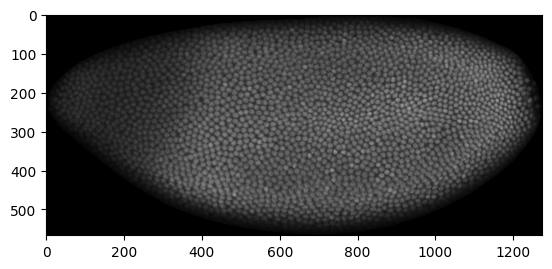

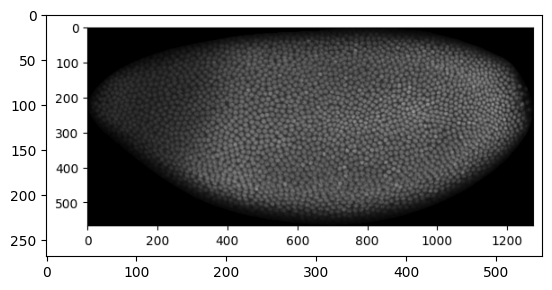

In [2]:
img1 = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img1, cmap='gray', vmin=0, vmax=255);

### Applying Watershed to `image.jpg` (original image)

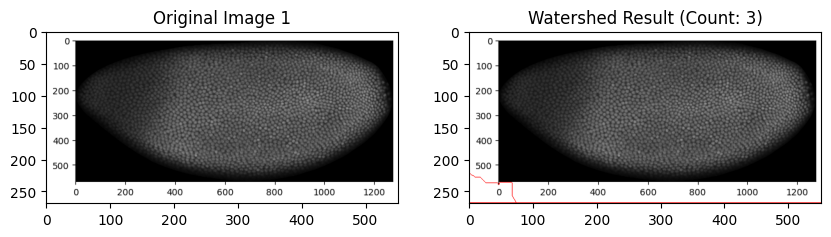

In [21]:
img1 = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

ret, thresh = cv2.threshold(img1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations = 2)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)

markers = cv2.watershed(img1_color, markers)
img1_color[markers == -1] = [255, 0, 0]

cell_count_original_img1 = len(np.unique(markers))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img1, cmap='gray'), plt.title('Original Image 1')
plt.subplot(122), plt.imshow(img1_color), plt.title(f'Watershed Result (Count: {cell_count_original_img1})')
plt.show()

### Applying Watershed to the gradient of `image.jpg`

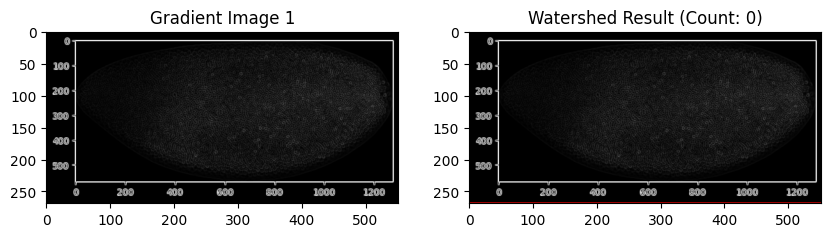

In [22]:
img1 = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

grad_x = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
gradient_img1 = cv2.magnitude(grad_x, grad_y)

gradient_img1 = cv2.normalize(gradient_img1, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

kernel = np.ones((3,3), np.uint8)
ret, thresh_grad = cv2.threshold(gradient_img1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

opening_grad = cv2.morphologyEx(thresh_grad, cv2.MORPH_OPEN, kernel, iterations = 2)

sure_bg_grad = cv2.dilate(opening_grad, kernel, iterations=3)

dist_transform_grad = cv2.distanceTransform(opening_grad, cv2.DIST_L2, 5)
ret, sure_fg_grad = cv2.threshold(dist_transform_grad, 0.7 * dist_transform_grad.max(), 255, 0)

sure_fg_grad = np.uint8(sure_fg_grad)
unknown_grad = cv2.subtract(sure_bg_grad, sure_fg_grad)

ret, markers_grad = cv2.connectedComponents(sure_fg_grad)

markers_grad = markers_grad + 1

markers_grad[unknown_grad == 255] = 0

gradient_img1_color = cv2.cvtColor(gradient_img1, cv2.COLOR_GRAY2BGR)

markers_grad = cv2.watershed(gradient_img1_color, markers_grad)
gradient_img1_color[markers_grad == -1] = [255, 0, 0] # Mark boundary with red

cell_count_gradient_img1 = len(np.unique(markers_grad)) - 2

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(gradient_img1, cmap='gray'), plt.title('Gradient Image 1')
plt.subplot(122), plt.imshow(gradient_img1_color), plt.title(f'Watershed Result (Count: {cell_count_gradient_img1})')
plt.show()

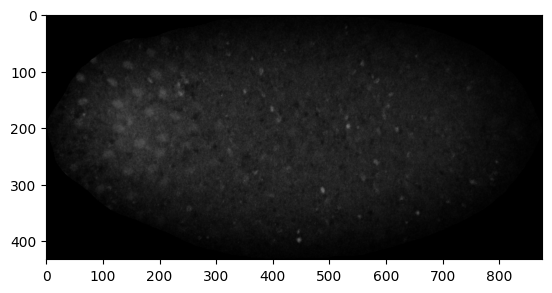

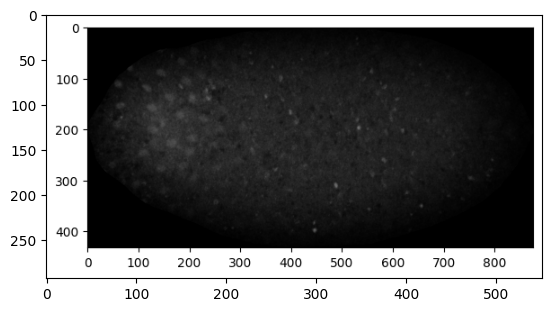

In [9]:
img2 = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img2, cmap='gray', vmin=0, vmax=255);

### Applying Watershed to `image2.jpg` (original image)

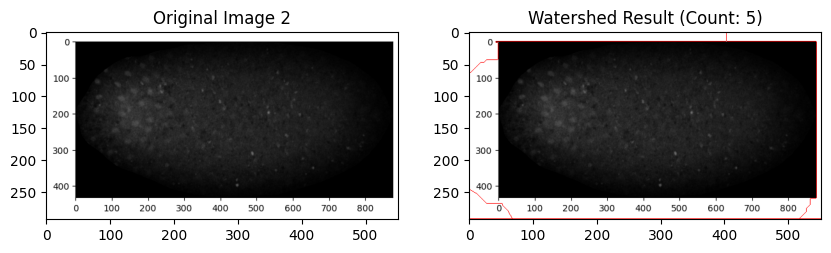

In [23]:
img2 = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)

ret, thresh2 = cv2.threshold(img2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3,3), np.uint8)
opening2 = cv2.morphologyEx(thresh2, cv2.MORPH_OPEN, kernel, iterations = 2)

sure_bg2 = cv2.dilate(opening2, kernel, iterations=3)

dist_transform2 = cv2.distanceTransform(opening2, cv2.DIST_L2, 5)
ret, sure_fg2 = cv2.threshold(dist_transform2, 0.7 * dist_transform2.max(), 255, 0)

sure_fg2 = np.uint8(sure_fg2)
unknown2 = cv2.subtract(sure_bg2, sure_fg2)

ret, markers2 = cv2.connectedComponents(sure_fg2)

markers2 = markers2 + 1

markers2[unknown2 == 255] = 0

img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

markers2 = cv2.watershed(img2_color, markers2)
img2_color[markers2 == -1] = [255, 0, 0]

cell_count_original_img2 = len(np.unique(markers2))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img2, cmap='gray'), plt.title('Original Image 2')
plt.subplot(122), plt.imshow(img2_color), plt.title(f'Watershed Result (Count: {cell_count_original_img2})')
plt.show()

### Applying Watershed to the gradient of `image2.jpg`

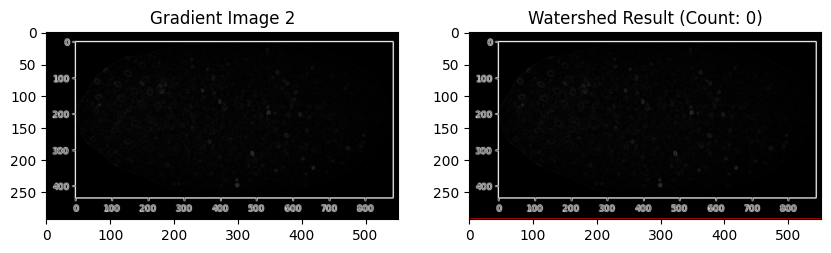

In [24]:
img2 = cv2.imread("image2.jpg", cv2.IMREAD_GRAYSCALE)

grad_x2 = cv2.Sobel(img2, cv2.CV_64F, 1, 0, ksize=3)
grad_y2 = cv2.Sobel(img2, cv2.CV_64F, 0, 1, ksize=3)
gradient_img2 = cv2.magnitude(grad_x2, grad_y2)

gradient_img2 = cv2.normalize(gradient_img2, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

kernel = np.ones((3,3), np.uint8)
ret, thresh_grad2 = cv2.threshold(gradient_img2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

opening_grad2 = cv2.morphologyEx(thresh_grad2, cv2.MORPH_OPEN, kernel, iterations = 2)

sure_bg_grad2 = cv2.dilate(opening_grad2, kernel, iterations=3)

dist_transform_grad2 = cv2.distanceTransform(opening_grad2, cv2.DIST_L2, 5)
ret, sure_fg_grad2 = cv2.threshold(dist_transform_grad2, 0.7 * dist_transform_grad2.max(), 255, 0)

sure_fg_grad2 = np.uint8(sure_fg_grad2)
unknown_grad2 = cv2.subtract(sure_bg_grad2, sure_fg_grad2)

ret, markers_grad2 = cv2.connectedComponents(sure_fg_grad2)

markers_grad2 = markers_grad2 + 1

markers_grad2[unknown_grad2 == 255] = 0

gradient_img2_color = cv2.cvtColor(gradient_img2, cv2.COLOR_GRAY2BGR)

markers_grad2 = cv2.watershed(gradient_img2_color, markers_grad2)
gradient_img2_color[markers_grad2 == -1] = [255, 0, 0] # Mark boundary with red

cell_count_gradient_img2 = len(np.unique(markers_grad2)) - 2

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(gradient_img2, cmap='gray'), plt.title('Gradient Image 2')
plt.subplot(122), plt.imshow(gradient_img2_color), plt.title(f'Watershed Result (Count: {cell_count_gradient_img2})')
plt.show()

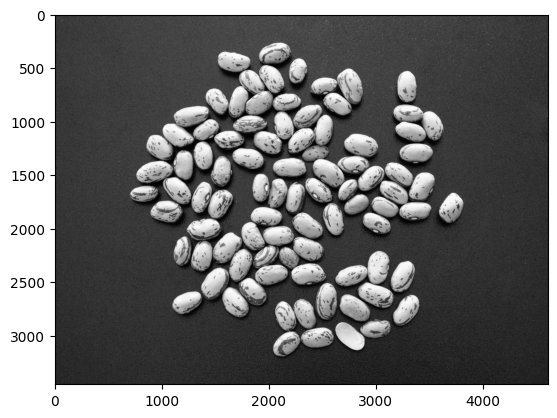

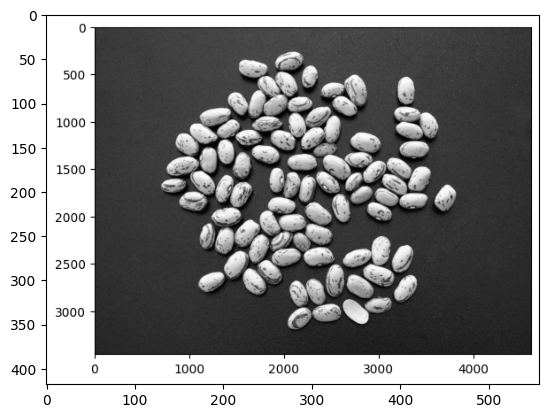

In [18]:
img3 = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img3, cmap='gray', vmin=0, vmax=255);

### Applying Watershed to `feijao.jpg` (original image)

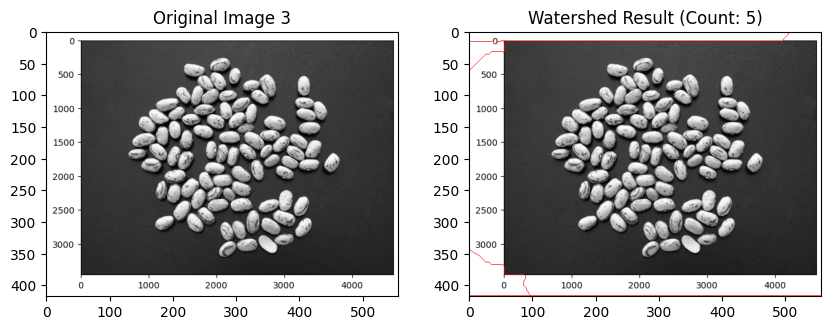

In [19]:
img3 = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)

ret, thresh3 = cv2.threshold(img3, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3,3), np.uint8)
opening3 = cv2.morphologyEx(thresh3, cv2.MORPH_OPEN, kernel, iterations = 2)

sure_bg3 = cv2.dilate(opening3, kernel, iterations=3)

dist_transform3 = cv2.distanceTransform(opening3, cv2.DIST_L2, 5)
ret, sure_fg3 = cv2.threshold(dist_transform3, 0.7 * dist_transform3.max(), 255, 0)

sure_fg3 = np.uint8(sure_fg3)
unknown3 = cv2.subtract(sure_bg3, sure_fg3)

ret, markers3 = cv2.connectedComponents(sure_fg3)

markers3 = markers3 + 1

markers3[unknown3 == 255] = 0

img3_color = cv2.cvtColor(img3, cv2.COLOR_GRAY2BGR)

markers3 = cv2.watershed(img3_color, markers3)
img3_color[markers3 == -1] = [255, 0, 0] # Mark boundary with red

cell_count_original_img3 = len(np.unique(markers3))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img3, cmap='gray'), plt.title('Original Image 3')
plt.subplot(122), plt.imshow(img3_color), plt.title(f'Watershed Result (Count: {cell_count_original_img3})')
plt.show()

### Applying Watershed to the gradient of `feijao.jpg`

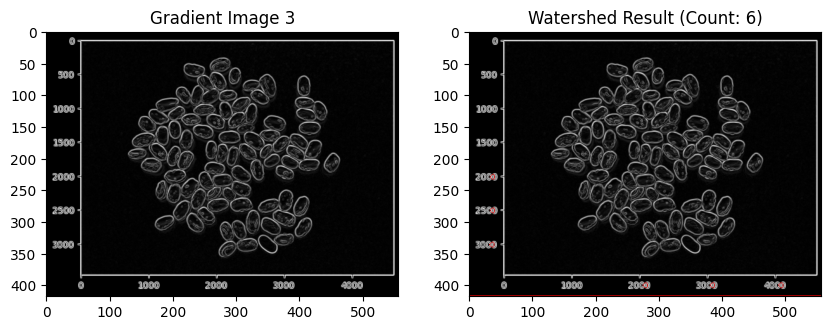

In [20]:
img3 = cv2.imread("feijao.jpg", cv2.IMREAD_GRAYSCALE)

grad_x3 = cv2.Sobel(img3, cv2.CV_64F, 1, 0, ksize=3)
grad_y3 = cv2.Sobel(img3, cv2.CV_64F, 0, 1, ksize=3)
gradient_img3 = cv2.magnitude(grad_x3, grad_y3)

gradient_img3 = cv2.normalize(gradient_img3, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

kernel = np.ones((3,3), np.uint8)
ret, thresh_grad3 = cv2.threshold(gradient_img3, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

opening_grad3 = cv2.morphologyEx(thresh_grad3, cv2.MORPH_OPEN, kernel, iterations = 2)

sure_bg_grad3 = cv2.dilate(opening_grad3, kernel, iterations=3)

dist_transform_grad3 = cv2.distanceTransform(opening_grad3, cv2.DIST_L2, 5)
ret, sure_fg_grad3 = cv2.threshold(dist_transform_grad3, 0.7 * dist_transform_grad3.max(), 255, 0)

sure_fg_grad3 = np.uint8(sure_fg_grad3)
unknown_grad3 = cv2.subtract(sure_bg_grad3, sure_fg_grad3)

ret, markers_grad3 = cv2.connectedComponents(sure_fg_grad3)

markers_grad3 = markers_grad3 + 1

markers_grad3[unknown_grad3 == 255] = 0

gradient_img3_color = cv2.cvtColor(gradient_img3, cv2.COLOR_GRAY2BGR)

markers_grad3 = cv2.watershed(gradient_img3_color, markers_grad3)
gradient_img3_color[markers_grad3 == -1] = [255, 0, 0] # Mark boundary with red

cell_count_gradient_img3 = len(np.unique(markers_grad3)) - 2

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(gradient_img3, cmap='gray'), plt.title('Gradient Image 3')
plt.subplot(122), plt.imshow(gradient_img3_color), plt.title(f'Watershed Result (Count: {cell_count_gradient_img3})')
plt.show()